# Experimento: ¿Alcanza con eliminar la variable sensible?

**Bootcamp Python – PY4**
**Módulo:** Machine Learning Avanzado y Feature Engineering  
**Laboratorio de IA Ética: Sesgos y Explicabilidad — Notebook bonus**

---

En la Sesión 3 encontramos que nuestro modelo sobre Adult Census Income se apoyaba fuertemente en la variable `sex`, y que reproducía casi exactamente la brecha de ingresos entre hombres y mujeres que ya existía en los datos históricos.

Frente a esto, la primera solución que se le ocurre a casi todo el mundo es: **"eliminemos la variable `sex` del modelo, y listo, el modelo ya no puede ser sexista."**

En este notebook vamos a poner esa idea a prueba. Vamos a entrenar dos modelos:

- **Modelo A:** con todas las variables, incluyendo `sex` (el mismo enfoque de la Sesión 3).
- **Modelo B:** exactamente las mismas variables, pero **sin** `sex`.

Y vamos a comparar tres cosas: el rendimiento de ambos modelos, qué variables usa cada uno según SHAP, y si la brecha entre hombres y mujeres realmente desaparece en las predicciones del Modelo B.

## 1. Preparar el entorno y cargar los datos

Usamos el mismo dataset y el mismo preprocesamiento de la Sesión 3.

In [1]:
!pip install xgboost shap scikit-learn joblib -q

In [2]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import joblib

In [3]:
url = "https://raw.githubusercontent.com/pooja2512/Adult-Census-Income/master/adult.csv"
df = pd.read_csv(url)

df = df.replace("?", np.nan).dropna()
df["income_bin"] = (df["income"] == ">50K").astype(int)

print("Filas:", df.shape[0])
df.head()

Filas: 30162


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,income_bin
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,0
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,0
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,0
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K,0
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K,0


Como referencia, recordemos la función que usamos para limpiar los nombres de columnas después de codificar las variables categóricas.

In [4]:
def limpiar_nombre_columna(col):
    col = col.replace("...", "")
    col = re.sub(r"[\[\]<>=,/:&()]", "", col)
    col = re.sub(r"[\s\.\-]+", "_", col.strip())
    col = re.sub(r"_+", "_", col).strip("_")
    return col.lower()

## 2. Entrenar el Modelo A: con todas las variables (incluyendo `sex`)

Este es exactamente el mismo modelo que entrenamos en la Sesión 3.

In [5]:
target = "income_bin"

X = df.drop(columns=["income", target])
y = df[target]

X_enc_A = pd.get_dummies(X, drop_first=True)
X_enc_A.columns = [limpiar_nombre_columna(c) for c in X_enc_A.columns]

Xa_train, Xa_test, y_train, y_test = train_test_split(
    X_enc_A, y, test_size=0.2, random_state=42, stratify=y
)

model_A = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    eval_metric="logloss", random_state=42
)
model_A.fit(Xa_train, y_train)

pred_A = model_A.predict(Xa_test)
print("Modelo A entrenado. Variables utilizadas:", Xa_train.shape[1])

Modelo A entrenado. Variables utilizadas: 96


## 3. Entrenar el Modelo B: las mismas variables, sin `sex`

La única diferencia con el Modelo A es que eliminamos la columna `sex` **antes** de codificar. Todo lo demás (mismas variables, mismo modelo, mismos hiperparámetros, mismo `random_state`) se mantiene igual, para que la comparación sea justa.

In [6]:
X_sin_sexo = X.drop(columns=["sex"])

X_enc_B = pd.get_dummies(X_sin_sexo, drop_first=True)
X_enc_B.columns = [limpiar_nombre_columna(c) for c in X_enc_B.columns]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_enc_B, y, test_size=0.2, random_state=42, stratify=y
)

model_B = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    eval_metric="logloss", random_state=42
)
model_B.fit(Xb_train, yb_train)

pred_B = model_B.predict(Xb_test)
print("Modelo B entrenado. Variables utilizadas:", Xb_train.shape[1])

Modelo B entrenado. Variables utilizadas: 95


## 4. Comparar el rendimiento: Modelo A vs. Modelo B

Si `sex` fuera una variable clave e insustituible para el modelo, esperaríamos que el Modelo B tuviera un rendimiento notablemente peor que el Modelo A al perderla. Veamos si es así.

In [7]:
comparacion = pd.DataFrame({
    "Modelo A (con sex)": [
        accuracy_score(y_test, pred_A),
        precision_score(y_test, pred_A),
        recall_score(y_test, pred_A),
        f1_score(y_test, pred_A),
    ],
    "Modelo B (sin sex)": [
        accuracy_score(yb_test, pred_B),
        precision_score(yb_test, pred_B),
        recall_score(yb_test, pred_B),
        f1_score(yb_test, pred_B),
    ],
}, index=["Accuracy", "Precision", "Recall", "F1-score"]).round(3)

comparacion

,Modelo A (con sex),Modelo B (sin sex)
Accuracy,0.874,0.875
Precision,0.806,0.809
Recall,0.652,0.650
F1-score,0.721,0.721


**Resultado esperado:** vas a notar que el rendimiento del Modelo B es prácticamente idéntico al del Modelo A (la diferencia es de milésimas). El modelo no perdió capacidad predictiva al perder `sex`.

Esto ya debería llamarte la atención: **si el modelo puede predecir igual de bien sin `sex`, es porque en algún lado del resto de las variables ya estaba esa misma información, de forma indirecta.**

## 5. Comparar qué variables usa cada modelo: SHAP

Calculemos la importancia SHAP para ambos modelos y comparemos los rankings.

In [8]:
explainer_A = shap.TreeExplainer(model_A)
shap_values_A = explainer_A(Xa_train)

importancia_A = pd.Series(
    np.abs(shap_values_A.values).mean(axis=0),
    index=Xa_train.columns
).sort_values(ascending=False)

print("Modelo A - Top 10 variables mas importantes:")
print(importancia_A.head(10))
print()
print("Ranking de sex_male en el Modelo A:", importancia_A.index.get_loc("sex_male") + 1, "de", len(importancia_A))

Modelo A - Top 10 variables mas importantes:
marital_status_married_civ_spouse    1.081553
age                                  0.641000
capital_gain                         0.466879
education_num                        0.463686
hours_per_week                       0.349148
sex_male                             0.145107
capital_loss                         0.141964
occupation_exec_managerial           0.129852
occupation_prof_specialty            0.100969
occupation_other_service             0.090981
dtype: float32

Ranking de sex_male en el Modelo A: 6 de 96


In [9]:
explainer_B = shap.TreeExplainer(model_B)
shap_values_B = explainer_B(Xb_train)

importancia_B = pd.Series(
    np.abs(shap_values_B.values).mean(axis=0),
    index=Xb_train.columns
).sort_values(ascending=False)

print("Modelo B - Top 10 variables mas importantes:")
print(importancia_B.head(10))

Modelo B - Top 10 variables mas importantes:
marital_status_married_civ_spouse    1.115656
age                                  0.633077
education_num                        0.460970
capital_gain                         0.458665
hours_per_week                       0.364638
capital_loss                         0.145212
occupation_exec_managerial           0.129793
occupation_prof_specialty            0.095686
occupation_other_service             0.094797
relationship_own_child               0.093723
dtype: float32


En nuestros resultados, `marital_status_married_civ_spouse` ya era la variable más importante del Modelo A, y en el Modelo B su importancia **aumenta todavía más** (de 1.08 a 1.12), absorbiendo buena parte de la señal que antes aportaba `sex`.

Esto no es casualidad: en este dataset de 1994, estar clasificado como `married-civ-spouse` está fuertemente correlacionado con ser hombre (por los roles familiares y laborales de la época). El modelo no necesita que le digamos explícitamente el sexo de la persona: le alcanza con saber su estado civil, su ocupación y otras variables correlacionadas para reconstruir prácticamente la misma información.

A esto se le llama una **variable proxy**: una variable que no es la variable sensible en sí misma, pero que está tan correlacionada con ella que termina cumpliendo la misma función dentro del modelo.

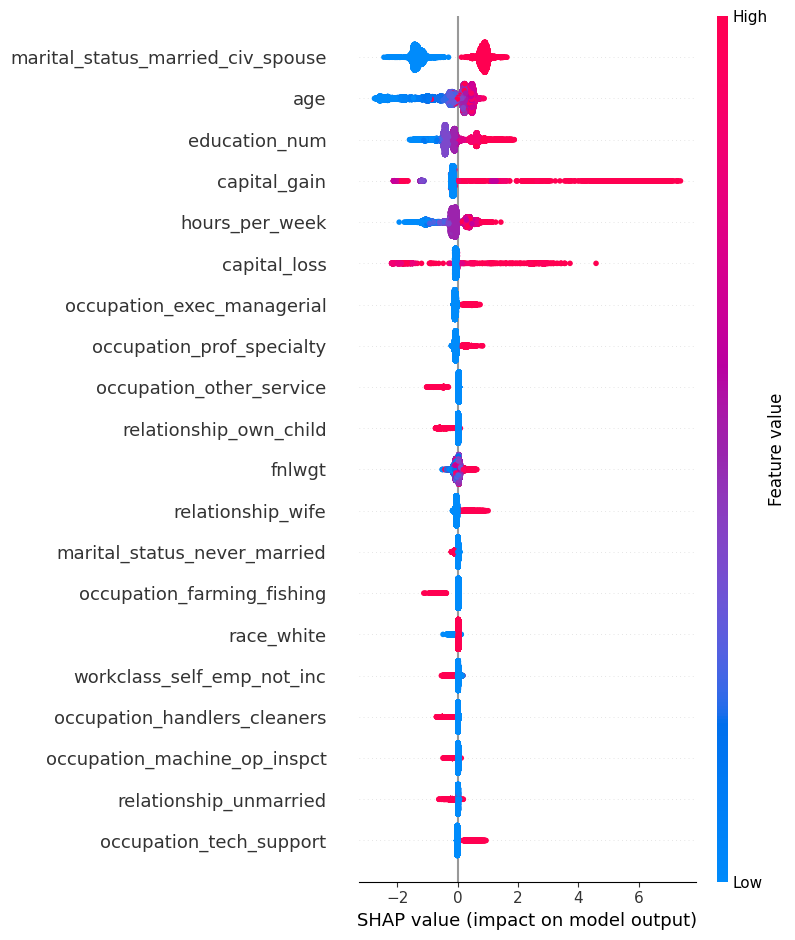

In [ ]:
# Comparacion visual: beeswarm del Modelo B
shap.summary_plot(shap_values_B, Xb_train, show=True)

Fíjate en este beeswarm: aunque ya no existe una columna `sex` en el dataset, `marital_status_married_civ_spouse`, `relationship_wife` y `relationship_own_child` siguen apareciendo entre las variables más influyentes. Todas ellas están relacionadas, directa o indirectamente, con el rol familiar y de pareja de una persona, que en 1994 estaba fuertemente ligado al sexo.

## 6. La pregunta clave: ¿el Modelo B es ahora justo?

Hasta acá, alguien podría pensar: "bueno, el modelo ya no *usa* `sex` directamente, así que el problema de fondo ya se resolvió, aunque otras variables se le parezcan un poco".

Para responder esto con evidencia y no con intuición, hagamos exactamente el mismo chequeo que hicimos en la Sesión 3: comparemos la tasa de predicción de "ingreso >50K" entre hombres y mujeres, pero ahora usando las predicciones del **Modelo B**, el que ni siquiera tiene acceso a esa columna.

In [ ]:
sexo_test_A = df.loc[Xa_test.index, "sex"]
sexo_test_B = df.loc[Xb_test.index, "sex"]

resultados_A = pd.DataFrame({"sex": sexo_test_A.values, "prediccion": pred_A})
resultados_B = pd.DataFrame({"sex": sexo_test_B.values, "prediccion": pred_B})

print("Tasa predicha de ingreso >50K por sexo - Modelo A (con sex):")
print(resultados_A.groupby("sex")["prediccion"].mean().round(3))
print()
print("Tasa predicha de ingreso >50K por sexo - Modelo B (SIN sex):")
print(resultados_B.groupby("sex")["prediccion"].mean().round(3))

Tasa predicha de ingreso >50K por sexo - Modelo A (con sex):
sex
Female    0.087
Male      0.255
Name: prediccion, dtype: float64

Tasa predicha de ingreso >50K por sexo - Modelo B (SIN sex):
sex
Female    0.089
Male      0.252
Name: prediccion, dtype: float64


**Este es el resultado central de todo el ejercicio.**

En nuestros datos, el Modelo A predice ingreso `>50K` para el 25.5% de los hombres y el 8.7% de las mujeres. El Modelo B, que ni siquiera tiene la columna `sex` disponible, predice **casi exactamente lo mismo**: 25.2% para hombres y 8.9% para mujeres.

Eliminar la variable sensible del dataset **no cambió prácticamente nada** el comportamiento del modelo hacia cada grupo. La brecha entre hombres y mujeres sigue ahí, intacta, solo que ahora el modelo la reconstruye a través de `marital_status`, `relationship`, `occupation` y otras variables correlacionadas.

## 7. Reflexión: ¿por qué pasa esto?

Este fenómeno se conoce en la literatura de fairness en Machine Learning como **"fairness through unawareness"** (equidad por desconocimiento), y es uno de los errores más comunes al intentar corregir sesgos: asumir que basta con quitarle al modelo el acceso directo a la variable sensible.

El problema es que, en el mundo real, casi ninguna variable sensible existe de forma aislada. El sexo de una persona está correlacionado con su estado civil, su ocupación, las horas que trabaja, su nivel educativo, y muchas otras variables, como resultado de patrones sociales e históricos. Si esas otras variables siguen en el dataset, un modelo lo suficientemente flexible (como XGBoost) puede reconstruir la información sensible de forma indirecta, sin necesidad de que se la demos explícitamente.

Esto no significa que eliminar la variable sensible sea inútil. Significa que **no es suficiente por sí sola**. Algunas preguntas para pensar:

- Si eliminar `sex` no resuelve el problema, ¿qué otras variables habría que revisar o eliminar también? ¿Dónde termina esa lista?
- ¿Existe un punto en el que eliminar tantas variables correlacionadas empieza a destruir información legítima y útil del modelo?
- ¿Qué otras estrategias, además de eliminar variables, existen para hacer que un modelo sea más equitativo? (por ejemplo: ajustar el umbral de decisión por grupo, entrenar con restricciones de fairness, auditar el modelo en producción de forma continua, etc.)

No hace falta responder todas estas preguntas hoy. La conclusión más importante de este notebook es más simple, y más incómoda: **remover una variable sensible del dataset no garantiza que el modelo deje de discriminar según esa variable.**